In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [8]:
data = np.load('formationchannels.npy')

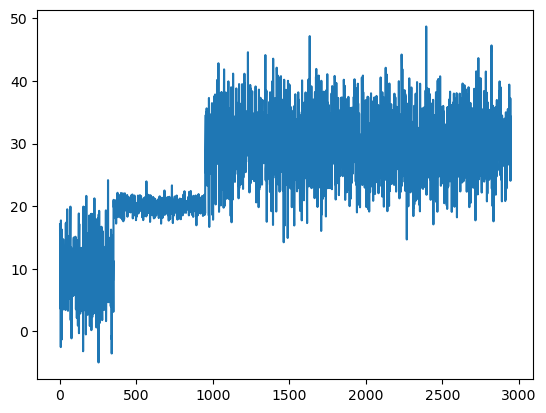

In [20]:
fig, ax = plt.subplots()
plt.plot(np.arange(0, len(data)), data)

(array([  1.,   2.,   1.,   4.,   3.,   5.,   4.,  12.,  14.,  17.,  28.,
         15.,  29.,  30.,  29.,  29.,  25.,  21.,  25.,  16.,  12.,  11.,
         28.,  74., 216., 243., 137.,  60.,  79.,  97.,  95., 122., 135.,
        144., 150., 163., 165., 139., 120., 115.,  83.,  71.,  52.,  51.,
         27.,  23.,  12.,   6.,   3.,   4.,   1.,   0.,   1.,   1.]),
 array([-4.96542500e+00, -3.97159779e+00, -2.97777057e+00, -1.98394336e+00,
        -9.90116147e-01,  3.71106587e-03,  9.97538279e-01,  1.99136549e+00,
         2.98519271e+00,  3.97901992e+00,  4.97284713e+00,  5.96667435e+00,
         6.96050156e+00,  7.95432877e+00,  8.94815599e+00,  9.94198320e+00,
         1.09358104e+01,  1.19296376e+01,  1.29234648e+01,  1.39172921e+01,
         1.49111193e+01,  1.59049465e+01,  1.68987737e+01,  1.78926009e+01,
         1.88864281e+01,  1.98802553e+01,  2.08740825e+01,  2.18679098e+01,
         2.28617370e+01,  2.38555642e+01,  2.48493914e+01,  2.58432186e+01,
         2.68370458e+01,  

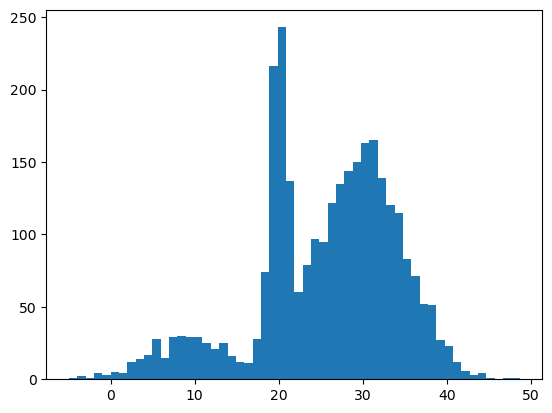

In [23]:
fig, ax = plt.subplots()
plt.hist(data, bins=round(np.sqrt(len(data))))

In [37]:
N_comp = np.arange(1, 11)

for i in range(10):
    
    model = GaussianMixture(n_components=N_comp[i])
    trained_model = model.fit(data)
    AIC = trained_model.aic(data)
    print(AIC)

20945.9726085902
20753.41195568149
20669.591357779103
20103.61434673094
20113.87270642974
20122.275296952575
20129.597448103003
20134.435379186718
20134.476002983432
20139.811093745826


In [46]:
def multigauss(x, mu, w, s):
    
    y = np.zeros(len(x))
    
    for i in range(len(mu)):
        y += w[i] * norm.pdf(x, loc=mu[i], scale=s[i])

    return y

In [53]:
mod = GaussianMixture(n_components=3)
train_mod = mod.fit(data)
means = train_mod.means_
weights = train_mod.weights_
sigmas = train_mod.covariances_

In [52]:
xarr = np.arange(min(data)[0], max(data)[0])
yarr = multigauss(xarr, means, weights, sigmas)

fig, ax = plt.subplots()
plt.hist(data, bins=round(np.sqrt(len(data))))
plt.plot(xarr, yarr, color='red')

ValueError: non-broadcastable output operand with shape (54,) doesn't match the broadcast shape (1,54)

Best model:  1
